In [3]:
import xarray as xr
import numpy as np
import pandas as pd
import numpy.linalg as lin
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from matplotlib.colors import Normalize
import cartopy.crs as ccrs
from matplotlib.colors import BoundaryNorm
from matplotlib.lines import Line2D
from matplotlib.font_manager import FontProperties
from xhistogram.xarray import histogram

In [4]:
plt.rcParams["font.family"] = "Arial"

In [5]:
def makedists(pdata, binl, bin_name):
    ##### This is called from within makeraindist.
    ##### Calculate distributions 
    bins=binl#np.append(0,binl)
    # this is the histogram - we'll get frequency from this
    thisn=histogram(pdata,dim=['time'], bins=[bins],block_size=None) 
    #### Calculate the number of days with non-missing data, for normalization
    ndmat=thisn.sum(dim=bin_name)
    thisppdfmap=thisn/ndmat
    #### Iterate back over the bins and add up all the precip - this will be the rain amount distribution
    testpamtmap=(thisn*getattr(thisn, bin_name)) ## This method is faster to process for the actual calculation (but will take way longer and more memory) try: #pdata.groupby_bins(pdata,bins).sum(dim='time')  
    thispamtmap=testpamtmap/ndmat
    return thisppdfmap, thispamtmap

In [6]:
#changed for time series
def make_bincrates():
    L=2.5e6
    maxp=1500;# % choose an arbitrary upper bound for initial distribution, in w/m2
    minp=.001;# % arbitrary lower bound, in w/m2. Make sure to set this low enough that you catch most of the rain. 
    #%%% thoughts: it might be better to specify the minimum threshold and the                                     
    #%%% bin spacing, which I have around 7%. The goals are to capture as much                                     
    #%%% of the distribution as possible and to balance sampling against                                           
    #%%% resolution. Capturing the upper end is easy: just extend the bins to                                      
    #%%% include the heaviest precipitation event in the dataset. The lower end                                    
    #%%% is harder: it can go all the way to machine epsilon, and there is no                                       
    #%%% obvious reasonable threshold for "rain" over a large spatial scale. The                                   
    #%%% value I chose here captures 97% of rainfall in CMIP5.                                                     
    nbins=100;
    binrlog=np.linspace(np.log(minp),np.log(maxp),nbins);
    dbinlog=np.diff(binrlog);
    binllog=binrlog-dbinlog[0];
    binr=np.exp(binrlog)/L*3600*24;
    binl=np.exp(binllog)/L*3600*24;
    dbin=dbinlog[0];
    binrlogex=binrlog;
    binrend=np.exp(binrlogex[len(binrlogex)-1])
    #% extend the bins until the maximum precip anywhere in the dataset falls
    #% within the bins
    # switch maxp to pmax if you want it to depend on your data
    while maxp>binr[len(binr)-1]:
        binrlogex=np.append(binrlogex,binrlogex[len(binrlogex)-1]+dbin)
        binrend=np.exp(binrlogex[len(binrlogex)-1]);
        binrlog=binrlogex;
        binllog=binrlog-dbinlog[0];
        binl=np.exp(binllog)/L*3600*24; #%% this is what we'll use to make distributions
        binr=np.exp(binrlog)/L*3600*24;
    bincrates=np.append(0,(binl+binr)/2)# % we'll use this for plotting.
    bincrates_real=bincrates[:-1]
    
    return bincrates_real

In [5]:
def calcrx1d(pamt,bincrates):
    p=1-(1/365.25)
    sc=np.cumsum(pamt)/np.sum(pamt)
    rx1day = np.interp(p, sc, bincrates)
    return rx1day

In [7]:
def calcbo(LRdist,HRdist,bincrates):
    scH=np.cumsum(HRdist)/np.sum(HRdist)
    scL=np.cumsum(LRdist)/np.sum(LRdist)
    p = 0.5
    rH = np.interp(p, scH, bincrates)
    rL = np.interp(p, scL, bincrates)
    bo = 100*((rH-rL)/rL)
    # centroids for further calculation
    lnrh2 = np.interp(p, scH, np.log(bincrates))
    lnrh1 = np.interp(p, scL, np.log(bincrates))
    db=(bincrates[2]-bincrates[1])/bincrates[1]  
    dpamt=HRdist-LRdist

    xp = np.log(bincrates[1:]) - lnrh1
    b = lnrh2 - lnrh1
    pamtbo = np.zeros(LRdist.shape)
    pamtbo[1:] = np.interp(xp - b, xp, LRdist[1:])
    err=100*np.nansum(np.abs(pamtbo[2:]-HRdist[2:]))/np.nansum(np.abs(dpamt[2:]))
    return (bo, pamtbo, err)

In [31]:
def shiftcalc(LRdist,HRdist,bincrates):


    db=(bincrates[2]-bincrates[1])/bincrates[1]  
    # calculate dp/dln(r)
    nb=len(LRdist);
    dpdlnrc= np.concatenate((np.array([0]),LRdist[2:nb]-LRdist[0:(nb-2)],np.array([0])))/(2*db) # centered difference (2nd order accurate; now used near endpoints)
    prm2=LRdist[:(nb-4)]
    prm1=LRdist[1:(nb-3)]
    prp1=LRdist[3:(nb-1)]
    prp2=LRdist[4:]
    dpdlnr= np.concatenate((np.array([0]),np.array([0]),8*(prp1-prm1)-(prp2-prm2),np.array([0]),np.array([0])))/(12*db) # 4th order accurate 
    dpdlnr[1]=dpdlnrc[1] # fill in with second order accurate near endpoints
    dpdlnr[nb-2]=dpdlnrc[nb-2] 

    dt=1
    
    dpamt=HRdist-LRdist
    # calculate the terms in the matrices that will need to be solved
    # (equation 10 in Pendergrass and Hartmann 2014, Two Modes of Change of the Distribution of Rain) 
    # calculate the terms in the matrices that will need to be solved
    # (equation 10 in Pendergrass and Hartmann 2014, Two Modes of Change of the Distribution of Rain) 
    spr2=np.nansum(LRdist**2)
    sdpdlnr2=np.nansum(dpdlnr**2)
    spdpdlnr=np.nansum(LRdist*dpdlnr)
    spdpm=np.nansum(LRdist*dpamt)
    sdpdlnrdpm=np.nansum(dpdlnr*dpamt)
    # set up the matrices
    B=np.array([[0],[-sdpdlnrdpm]])
    A=np.array([[0,-spdpdlnr],[0,sdpdlnr2]])

    try:
        x = np.linalg.solve(A, B)
    except np.linalg.LinAlgError:
        #print("Matrix is singular, using pseudo-inverse.")
        x = np.linalg.pinv(A) @ B
    shift=100*x[1] # shift mode (%)
    pamtshift=-x[1]*dpdlnr+LRdist
    err=100*np.nansum(np.abs(pamtshift[2:]-HRdist[2:]))/np.nansum(np.abs(dpamt[2:]))

    return (shift,pamtshift,err)

# Figure-2: Plotting the rainfall distributions and rx1day values

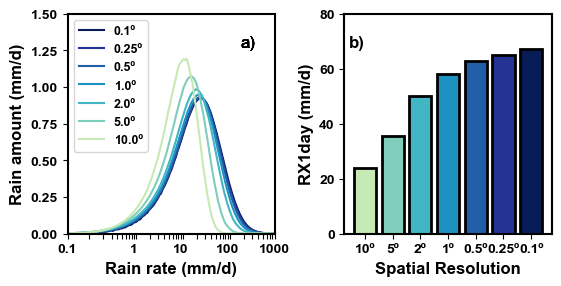

In [15]:
# AMS standard figure widths in inches
ams_sizes = {
    "one_column": 3.2,
    "two_thirds": 4.5,
    "two_columns": 5.5,
    "more_than_two_columns": 6.5,
}

# Common aspect ratio: width : height = 4:3 → height = width * 0.75
# You can change this based on the visual needs of your plot
aspect_ratio = 0.5


width = ams_sizes["two_columns"]
height = width * aspect_ratio
low_res = 25 #100 ## spatial resolution of low res dataset in kilometers
data1= xr.open_dataset('./../data/spatial/dist_data/raindist_data_10_'+str(low_res)+'km.nc') ## Reading in data. Current structure is that the high resolution distribution is available in both input files.
bincrates=data1.precipitation_bin[1:].values ## rain rate bins
## Plotting begins here
res=[10,25,50,100,200,500,1000]
colrs=['#081d58','#253494','#225ea8','#1d91c0','#41b6c4','#7fcdbb','#c7e9b4']
n=0
count=0

otn=np.linspace(1,9,9)
xtickrates=np.append(0,otn*.1)
xtickrates=np.append(xtickrates,otn)
xtickrates=np.append(xtickrates,otn*10)
xtickrates=np.append(xtickrates,otn*100)
xticks=np.interp(xtickrates,bincrates,range(0,len(bincrates))); #% bin numbers associated with nice number rain rate
xticks,indices=np.unique(xticks,return_index=True)
xtickrates=xtickrates[indices]
### Bin width - needed to normalize the rain amount distribution
db=(bincrates[2]-bincrates[1])/bincrates[1];

## Calculate rx1day by reading pre-computed rx1day files and averaging
res_labels = ["10km", "25km", "50km", "100km", "200km", "500km", "1000km"]
rx = []
for rl in res_labels:
    ds = xr.open_dataset(f"./../data/spatial/rx1day/rx1day_data_{rl}.nc")
    rx1_mean = ds.rx1day_spatial.mean().values
    rx.append(float(rx1_mean))

### Now we plot
plt.figure(figsize=(width,height), constrained_layout=True)
plt.clf()

ax=plt.subplot(121)
for i in range(0,len(res)):
    
    if i==0:
        data1= xr.open_dataset('./../data/spatial/dist_data/raindist_data_'+str(res[i])+'_25km.nc')## Reading in data. Current structure is that the high resolution distribution is available in both input files.
        pamt = data1.pamtH[1:].values ## rain amount of HR dataset
    else:
        data1= xr.open_dataset('./../data/spatial/dist_data/raindist_data_10_'+str(res[i])+'km.nc')
        pamt= data1.pamtL[1:].values ## rain amount of LR dataset
    plt.plot(range(0,len(pamt)),pamt/db, color=colrs[i], label=str(res[i]/100)+'º',linewidth=1.5)
    plt.xlim((4,130))
    plt.ylim((0,1.5))
    legend_properties = {'weight':'bold','size':9}
    plt.legend(prop=legend_properties)

    ### Annotate with the dry day frequency
    ymin, ymax = ax.get_ylim()
    t1=plt.text(115,ymax*0.90, 'a)',fontsize=12)
    #t2=plt.text(4,ymax*0.90, "{:.1f}".format(dryH)+'%',color='m')
    plt.setp(t1,va='top',ha='left')
    #plt.setp(t2,va='top',ha='left')
    plt.setp(ax,xticks=xticks,xticklabels=['0.1','','','','','','','','','1','','','','','','','','','10','','','','','','','','','100','','','','','','','','','1000'])
    plt.xlabel('Rain rate (mm/d)',fontsize=12,fontweight="bold")
    plt.ylabel('Rain amount (mm/d)',fontsize=12,fontweight="bold")
    plt.xticks(fontsize=10,fontweight="bold")
    plt.yticks(fontsize=10,fontweight="bold")
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(1.5)
    count+=1
ax2=plt.subplot(122)
rd=pd.DataFrame(rx)
x=['0.1º','0.25º','0.5º','1º','2º','5º','10º']
plt.bar(x[::-1],rx[::-1],color=colrs[::-1],edgecolor='black', linewidth=2)
plt.xlabel('Spatial Resolution',fontsize=12,fontweight="bold")    
plt.ylabel('RX1day (mm/d)',fontsize=12,fontweight="bold")
plt.ylim([0,80])
plt.xticks(fontsize=10,fontweight="bold")
plt.yticks(fontsize=10,fontweight="bold")
ymin, ymax = ax2.get_ylim()
t2=plt.text(0,ymax*0.90, 'b)',fontsize=12,fontweight='bold')
plt.setp(t2,va='top',ha='right')
for axis in ['top','bottom','left','right']:
    ax2.spines[axis].set_linewidth(1.5)

filename='./../figs/fig2_rain_amount.pdf'
#plt.savefig(filename, format="pdf", bbox_inches="tight",dpi=300)
#plt.close()

# Figure-3: Joint rain amount distributions distributions for spatial scaling

In [31]:
otn=np.linspace(1,9,9)
xtickrates=np.append(0,otn*.1)
xtickrates=np.append(xtickrates,otn)
xtickrates=np.append(xtickrates,otn*10)
xtickrates=np.append(xtickrates,otn*100)
xticks=np.interp(xtickrates,bincrates,range(0,len(bincrates))); #% bin numbers associated with nice number rain rate
xticks,indices=np.unique(xticks,return_index=True)
xtickrates=xtickrates[indices]
### Bin width - needed to normalize the rain amount distribution
db=(bincrates[2]-bincrates[1])/bincrates[1];

ams_sizes = {
    "one_column": 3.2,
    "two_thirds": 4.5,
    "two_columns": 5.5,
    "more_than_two_columns": 6.5,
}

# Common aspect ratio: width : height = 4:3 → height = width * 0.75
# You can change this based on the visual needs of your plot
aspect_ratio = 1


width = 10#ams_sizes["more_than_two_columns"]
height = width * aspect_ratio
res = [1000, 500, 200, 100,50, 25, 10]  # in km; equivalent to 10º, 5º, ..., 0.1º
res_hr = res[::-1]          # what you already use for rows (HR)
res_lr = res[::-1]          # <-- flip columns by using reversed LR too
plabel=['a)','b)','c)','d)','e)','f)','g)','h)','i)','j)','k)','l)','m)','n)','o)','p)','q)','r)','s)','t)','u)','v)']
n=0
lr=0
pl=0
nrows=len(res)
fig = plt.figure(figsize=(width, height))
plt.subplots_adjust(wspace=0.2, hspace=0.18, bottom=0.0, left=-0.1, right=0.9, top=0.9)
for i in range(nrows):      # rows (do NOT flip)
    hr = res_hr[i]
    first_valid_col = None
    last_valid_col = nrows-1
    for j in range(nrows):  # columns (flipped)
        lr = res_lr[j]

        # ---- skip diagonal and below (so you never request hr==lr) ----
        # indices in the ORIGINAL res list:
        hr_idx = nrows - 1 - i           # because hr = res[::-1][i]
        lr_idx = nrows - 1 - j           # because lr = res[::-1][j]

        if lr_idx >= hr_idx:             # lr >= hr in the index sense -> diagonal/below
            continue    
        if first_valid_col is None:
            first_valid_col = j     
        data3= xr.open_dataset(f'./../data/spatial/dist_data/rainjointdist_data_{hr}_{lr}km.nc')
        jdL=data3.jdL
        jdH=data3.jdH
        jdF=data3.jdF
        
        ax = fig.add_subplot(nrows, nrows, i * nrows + j + 1)

        levels=np.arange(0.0001,0.001,0.0002)
        cs1=ax.contour(np.arange(0,len(jdH.LR_bin[1:])),np.arange(0,len(jdH.HR_bin[1:])),jdH[1:,1:].T,linewidths=1,colors='#081d58',levels=levels)
        cs2=ax.contour(np.arange(0,len(jdL.LR_bin[1:])),np.arange(0,len(jdL.HR_bin[1:])),jdL[1:,1:].T,linewidths=1,colors='#1d91c0',levels=levels,alpha=0.8)
        
        #plt.clabel(cs1, inline=1, fontsize=20)
        #plt.clabel(cs2, inline=1, fontsize=20)

        ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
        ax.tick_params(labelleft=False, left=False)
        lims = [
            np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
            np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
        ]
        
        # now plot both limits against eachother
        ax.plot(lims, lims, 'k-', alpha=0.5)
        ax.set_aspect('equal')
        ax.set_xlim(lims)
        ax.set_ylim(lims)
        for axis in ['top','bottom','left','right']:
            ax.spines[axis].set_linewidth(1.5)
        ymin, ymax = ax.get_ylim()
        t3=plt.text(5,ymax*0.925, plabel[n]+' '+str(lr/100)+'º → '+str(res[::-1][i]/100)+'º',fontsize=10,fontweight="bold")
        plt.setp(t1,va='top',ha='left')
        plt.setp(t2,va='top',ha='left')
        plt.setp(t3,va='top',ha='left')
        
        if i==0:
            ax.text(0.5,1.2, str(lr/100)+'º', fontsize=14, fontweight="bold", color='#1d91c0', transform=ax.transAxes, ha='center', rotation=0, va='center')
        if j == first_valid_col:
            ax.tick_params(axis='x', which='both', bottom=True, top=False, labeltop=False, labelbottom=True)
            ax.set_xlabel('LR rain rate', fontsize=10, fontweight="bold")
            ax.set_xticks(xticks)  # Optional: no ticks
            ax.set_xticklabels(['0.1','','','','','','','','','1','','','','','','','','','10','','','','','','','','','100','','','','','','','','','1000'],fontsize=8,fontweight="bold")
            ax.text(-0.2,0.5, str(res[::-1][i]/100)+'º', fontsize=14, fontweight="bold", color='#081d58', transform=ax.transAxes, ha='left', rotation=90, va='center')
        if j == last_valid_col:  # last valid column (just before diagonal)
            ax.tick_params(axis='y', right=True,labelright=True,labelleft=False, left=False)
            ax.yaxis.set_label_position("right")
            ax.set_ylabel('HR rain rate', fontsize=10, fontweight="bold")
            ax.set_yticks(xticks)  # Optional: no ticks
            ax.set_yticklabels(['0.1','','','','','','','','','1','','','','','','','','','10','','','','','','','','','100','','','','','','','','','1000'],fontsize=8,fontweight="bold")
        plt.xlim((0,138))
        plt.ylim((0,138))
        n+=1
        pl=pl+1
         
# Create a full-figure invisible Axes for annotation
fig_ax = fig.add_axes([0, 0, 1, 1], zorder=-1)
fig_ax.axis('off')  # Hide everything

# Add an arrow across the figure
fig_ax.annotate(
    '',  # no text
    xy=(0.7, 0.15),  # tail location
    xytext=(0.2, 0.15),  # arrowhead location in figure coords
    xycoords='figure fraction',
    textcoords='figure fraction',
    arrowprops=dict(arrowstyle="->", linewidth=3, color='#1d91c0')
)
# Text just above the arrow (you can move it below by reducing 0.12 to 0.08)
fig.text(0.45, 0.16, 'Coarser Low Resolution (LR)', ha='center', va='bottom',
         fontsize=14, fontweight='bold', color='#1d91c0')


# Vertical arrow (right side of figure)
fig_ax = fig.add_axes([0, 0, 1, 1], zorder=-1)
fig_ax.axis('off')  # Hide everything
fig_ax.annotate(
    '', 
    xy=(0.1, 0.7),       # arrowhead at top
    xytext=(0.1, 0.2),   # tail at bottom
    xycoords='figure fraction',
    textcoords='figure fraction',
    arrowprops=dict(arrowstyle='->', linewidth=3,color='#081d58'),
)

# Label just to the left of the arrow
fig.text(0.12, 0.45, 'Finer Higher Resolution (HR)', rotation=90,
         va='center', ha='right', fontsize=14, fontweight='bold',color='#081d58')

filename='./../figs/fig3_joint_dist.pdf'
plt.savefig(filename, format="pdf", bbox_inches="tight",dpi=300)
plt.close()

            

# Figure-5: Rain amount differences and shift values

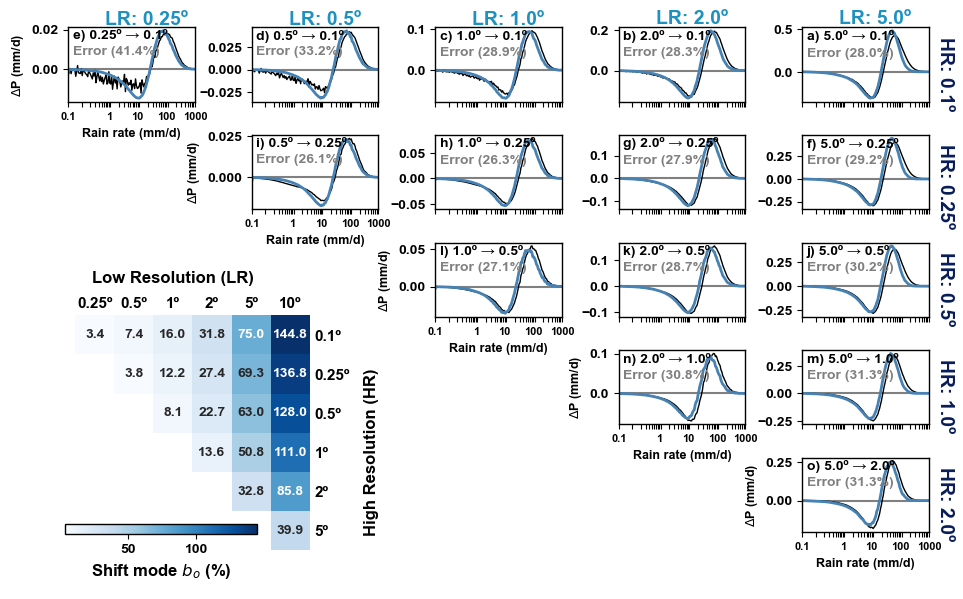

In [14]:
## Calculating bo
otn=np.linspace(1,9,9)
xtickrates=np.append(0,otn*.1)
xtickrates=np.append(xtickrates,otn)
xtickrates=np.append(xtickrates,otn*10)
xtickrates=np.append(xtickrates,otn*100)
xticks=np.interp(xtickrates,bincrates,range(0,len(bincrates))); #% bin numbers associated with nice number rain rate
xticks,indices=np.unique(xticks,return_index=True)
xtickrates=xtickrates[indices]
### Bin width - needed to normalize the rain amount distribution
db=(bincrates[2]-bincrates[1])/bincrates[1];

ams_sizes = {
    "one_column": 3.2,
    "two_thirds": 4.5,
    "two_columns": 5.5,
    "more_than_two_columns": 6.5,
}

# Common aspect ratio: width : height = 4:3 → height = width * 0.75
# You can change this based on the visual needs of your plot
aspect_ratio = 0.6


width = 12#ams_sizes["two_columns"]
height = width * aspect_ratio
res = [ 500,200, 100,50, 25, 10]  # in km; equivalent to 10º, 5º, ..., 0.1º
plabel=['a)','b)','c)','d)','e)','f)','g)','h)','i)','j)','k)','l)','m)','n)','o)']
n=1
lr=0
pl=0
nrows=len(res)
fig = plt.figure(figsize=(width, height))
lr_labeled_cols = set()
ylabel_rows = set()
hr_labeled_rows = set()
xlabel_axes = {}  # track which axis in each row gets x-label and x-ticks
for i in range(0,len(res)):
    lr+=1
    for ii in range(0,len(res)):

        if res[ii]==res[::-1][i]:
            break

        data1= xr.open_dataset('./../data/spatial/dist_data/raindist_data_'+str(res[::-1][i])+'_'+str(res[ii])+'km.nc')
        pamtH = data1.pamtH[1:].values
        pamtL = data1.pamtL[1:].values
        bincrates=data1.precipitation_bin[1:].values ## rain rate bins
        db=(bincrates[2]-bincrates[1])/bincrates[1];
        modes =calcbo(pamtL,pamtH,bincrates)
        pamtshift = modes[1]
        err=modes[2]

        Po1=(pamtshift)-pamtL ## Difference in rain amount at 0.1º and shifted 1º 
        Po=((pamtH)-(pamtL))

        ### Plotting the difference between HR and LR' combined plot

        col = nrows - 1 - ii
        ax = fig.add_subplot(nrows, nrows, i * nrows + col + 1)
        plt.subplots_adjust(wspace=0.45, hspace=0.45, bottom=0.1, top=0.95, right=0.95, left=0.08)

        lwidth=2

        plt.axhline(y = 0, color = 'gray')
        plt.plot(range(0,len(Po)),Po/db,color='black',linewidth=1,label=str(res[ii]/100)+'º-'+str(res[::-1][i]/100)+'º Difference')
        plt.plot(range(0,len(Po1)),Po1/db,color='steelblue',linewidth=lwidth,label=str(res[ii]/100)+'º-'+str(res[::-1][i]/100)+'º Shift')
        
        plt.xlim((4,130))

        ymin, ymax = ax.get_ylim()
        plt.text(5,ymax*0.72, plabel[pl]+' '+str(res[ii]/100)+'º → '+str(res[::-1][i]/100)+'º',fontsize=10,fontweight="bold")
        plt.text(5,ymax*0.35,'Error ('+str(round(err,1))+'%)',color='grey',fontsize=10,fontweight="bold")

        # styling for all panels
        for spine in ax.spines.values():
            spine.set_linewidth(1)
        plt.yticks(fontsize=10,weight='bold')

        # Add LR label once per column (top of column)
        if col not in lr_labeled_cols:
            t4 = plt.text(40,ymax*1.4, 'LR: '+str(res[ii]/100)+'º',fontsize=14,fontweight="bold",color='#1d91c0')
            plt.setp(t4,va='top',ha='left')
            lr_labeled_cols.add(col)

        # Add y-axis label once per row
        if i not in ylabel_rows:
            plt.ylabel('$\\mathbf{\\mathit{\\Delta}}$P (mm/d)',fontsize=12,weight='bold')
            ylabel_rows.add(i)

        # Add HR label once per row (right side)
        if i not in hr_labeled_rows:
            t5 = plt.text(145,ymax*0.8, 'HR: '+str(res[::-1][i]/100)+'º', rotation=270,fontsize=14,fontweight="bold",color='#081d58')
            plt.setp(t5,va='top',ha='left')
            hr_labeled_rows.add(i)

        # Only the left-most (first) panel in each row keeps x-ticks and x-label
        prev_ax = xlabel_axes.get(i)
        if prev_ax is not None:
            prev_ax.set_xlabel('')
            prev_ax.set_ylabel('')
            prev_ax.set_xticklabels([])

        plt.setp(ax,xticks=xticks,xticklabels=['0.1','','','','','','','','','1','','','','','','','','','10','','','','','','','','','100','','','','','','','','','1000'])
        plt.xticks(fontsize=8,weight='bold')
        ax.set_xlabel('Rain rate (mm/d)',fontsize=9,weight='bold')
        ax.set_ylabel('$\\mathbf{\\mathit{\\Delta}}$P (mm/d)',fontsize=9,weight='bold')
        xlabel_axes[i] = ax

        n+=1
        pl=pl+1
        if res[ii]==res[-1]:
            n=n+(i+1)

res=[ 1000, 500, 200, 100,50, 25, 10]
shift_matrix = np.full((len(res), len(res)), np.nan)
for i in range(0,len(res)):
    for ii in range(0,len(res)):
        if res[ii]==res[::-1][i]:
            break
        data1= xr.open_dataset('./../data/spatial/dist_data/raindist_data_'+str(res[::-1][i])+'_'+str(res[ii])+'km.nc')
        pamtH = data1.pamtH[1:].values
        pamtL = data1.pamtL[1:].values
        bincrates=data1.precipitation_bin[1:].values ## rain rate bins
        db=(bincrates[2]-bincrates[1])/bincrates[1];
        modes = calcbo(pamtL,pamtH,bincrates)
        #bmax= 100*((res[ii]**2)/(res[::-1][i]**2))
        #bmax= -100*(((res[::-1][i]**2)/(res[ii]**2))-1)
        shift_matrix[ii, i] = (modes[0].item())
#modified_matrix = shift_matrix[:, 1:]  # drop first column for x-axis
        
# Add a new axes at bottom left (custom position)
# [left, bottom, width, height] in fraction of figure dimensions (0 to 1)
ax2 = fig.add_axes([0.12, 0.15, 0.4, 0.4])  # adjust values to fit your layout

shift_matrix_plot = shift_matrix.T[:, ::-1]

sns.heatmap(
    shift_matrix_plot,
    xticklabels=['','0.25º','0.5º','1º','2º','5º','10º'],
    yticklabels=['0.1º','0.25º','0.5º','1º','2º','5º',''],  # reverse y-axis to match top-left origin
    cmap='Blues',
    annot=True, fmt=".1f",
    annot_kws={"fontsize": 10, "fontweight": "bold"},
    cbar_kws={
        "label": "Shift (%)",
        "orientation": "horizontal",
        "pad": -0.1,
        "shrink": 0.4
    },
    #vmin=0, vmax=10,
    square=True
)
# Modify colorbar appearance
cbar = ax2.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)
cbar.set_label("Shift mode $b_o$ (%)", fontsize=12, fontweight='bold')

# Manually shift the colorbar to the right
pos = cbar.ax.get_position()
cbar.ax.set_position([pos.x0 - 0.01, pos.y0+0.05, pos.width, pos.height])  # shift x0 right by 0.05
cbar.ax.tick_params(labelsize=10)  # font size
for label in cbar.ax.get_xticklabels():  # for horizontal
    label.set_fontweight('bold')

# 2. Set bold colorbar border (outline)
for spine in cbar.ax.spines.values():
    spine.set_linewidth(1)
    spine.set_edgecolor('black')

# Enable top x-axis and left y-axis ticks
ax2.xaxis.tick_top()
ax2.yaxis.tick_left()

# Ensure tick labels are shown
ax2.tick_params(
    top=True, labeltop=True,
    left=False, labelleft=False,
    bottom=False, labelbottom=False,
    right=True, labelright=True,
    length=0  # Hides the tick lines
)

# Set bold and fontsize for tick labels
plt.setp(ax2.get_xticklabels(), fontsize=11, fontweight='bold')
plt.setp(ax2.get_yticklabels(), fontsize=11, rotation=0,fontweight='bold')
ax2.set_xlabel('Low Resolution (LR)', fontsize=12, fontweight='bold', labelpad=10)
ax2.xaxis.set_label_position('top')
ax2.set_ylabel('High Resolution (HR)', fontsize=12, fontweight='bold', labelpad=10)
ax2.yaxis.set_label_position('right')
plt.ylabel('High Resolution (HR)', fontsize=12, fontweight='bold')
#plt.setp(ax2.get_xticklabels(), fontsize=10, fontweight='bold')
#plt.setp(ax2.get_yticklabels(), rotation=360, fontsize=10, fontweight='bold')
filename='./../figs/fig5_rain_diff.pdf'
#plt.savefig(filename, format="pdf", bbox_inches="tight",dpi=300)
#plt.close()

# Figure-6: Fitted vs. direct shift mode

In [32]:
res=[10,25,50,100,200,500,1000]
n=0
LRc=[]

sm=[];si=[]
for i in range(1,len(res)):
    n=n+1
    data1= xr.open_dataset('./../data/spatial/dist_data/raindist_data_10_'+str(res[i])+'km.nc')## Reading in data. Current structure is that the high resolution distribution is available in both input files.
    pamtH = data1.pamtH[1:].values ## rain amount of HR dataset
    pamtL= data1.pamtL[1:].values ## rain amount of LR dataset
    ppdfH= data1.ppdfH[1:].values ## rain frequency of HR dataset
    ppdfL=data1.ppdfL[1:].values ## rain frequency of LR dataset
    bincrates=data1.precipitation_bin[1:].values ## rain rate bins
    omodes=calcbo(pamtL,pamtH,bincrates)
    modes = shiftcalc(pamtL,pamtH,bincrates)

    sm.append(modes[0])
    si.append(omodes[0])
    LRc.append(str(res[i]/100)+'º')

shiftm=np.concatenate(sm)
#shifti=np.concatenate(si)
#LR=np.concatenate(LRc)
df=pd.DataFrame({'LR' :LRc,'b' : np.round(shiftm,2),'bo' : np.round(si,2)})

In [34]:
# AMS standard figure widths in inches
ams_sizes = {
    "one_column": 3.2,
    "two_thirds": 4.5,
    "two_columns": 5.5,
    "more_than_two_columns": 6.5,
}

# Common aspect ratio: width : height = 4:3 → height = width * 0.75
# You can change this based on the visual needs of your plot
aspect_ratio = 1


width = ams_sizes["one_column"]
height = width * aspect_ratio
colrs1=['#d0d1e6','#a6bddb','#74a9cf','#3690c0','#0570b0','#034e7b']

plt.figure(figsize=(width,height), constrained_layout=True)
plt.clf()
ax=plt.subplot(111)
sns.scatterplot(x='bo',y='b',s=100,data=df,hue="LR",palette=colrs1[::-1])
plt.xlim([-1,151])
plt.ylim([-1,151])
plt.xlabel('Direct Shift Mode $b_o$ (%)',fontsize=12,fontweight="bold")
plt.ylabel('Fitted Shift Mode b (%)',fontsize=12,fontweight="bold")
plt.xticks(fontsize=10,weight='bold')
plt.yticks(fontsize=10,weight='bold')
lims = [
            np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
            np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
        ]

# now plot both limits against eachother
ax.plot(lims, lims, 'grey', alpha=0.75)
ax.set_aspect('equal')
ax.set_xlim(lims)
ax.set_ylim(lims)
bold_font = FontProperties(weight='bold', size=10)
plt.legend(prop=bold_font)
filename='./../figs/fig6_bo_b.pdf'
plt.savefig(filename, format="pdf", bbox_inches="tight",dpi=300)
plt.close()

# Figure-7: Spatial variability of shift mode and their errors

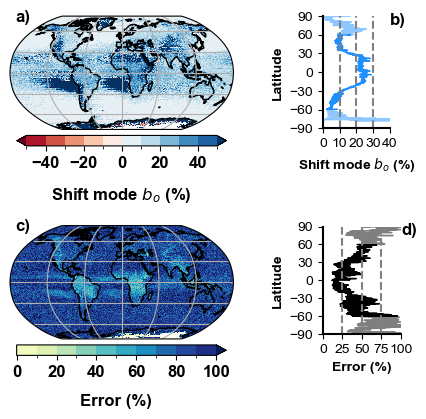

In [16]:
%timeit
sdata=xr.open_dataset('./../data/spatial/bo_10_100km_10v.nc')
zdata=xr.open_dataset('./../data/spatial/bo_zonal_10_100km.nc')
sh_trop=zdata['shift'].sel(lat=slice(-60,60));sh_N=zdata['shift'].sel(lat=slice(60,90));sh_S=zdata['shift'].sel(lat=slice(-90,-60))
er_trop=zdata['error'].sel(lat=slice(-60,60));er_N=zdata['error'].sel(lat=slice(60,90));er_S=zdata['error'].sel(lat=slice(-90,-60))
ams_sizes = {
    "one_column": 3.2,
    "two_thirds": 4.5,
    "two_columns": 5.5,
    "more_than_two_columns": 6.5,
}

# Common aspect ratio: width : height = 4:3 → height = width * 0.75
# You can change this based on the visual needs of your plot
aspect_ratio = 0.65


width = ams_sizes["more_than_two_columns"]
height = width * aspect_ratio

# Extract lat, lon, and data (ensure it's 2D)
levels=np.arange(-50,60,10)
cmap = plt.get_cmap('RdBu', len(levels)+1)  # Discretize the colormap
norm = BoundaryNorm(boundaries=levels, ncolors=cmap.N, extend='both')

# Plot
fig = plt.figure(figsize=(width, height))
plt.subplots_adjust(wspace=0.4, hspace=0.4, bottom=0.1, right=0.95, top=0.95)

lon, lat = np.meshgrid(sdata['lon'], sdata['lat'])
ax1 = fig.add_subplot(2, 2, 1, projection=ccrs.Robinson())
pcm1 = ax1.pcolormesh(
    lon, lat, sdata['shift'].T,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    norm=norm,
    shading='auto'
)
pcm1.set_rasterized(True)

ax1.coastlines()
ax1.gridlines()
ymin, ymax = ax1.get_ylim()
xmin, xmax = ax1.get_xlim()
plt.text(0.95*xmin,0.90*ymax,'a)',fontsize=12,fontweight='bold')

cbar = fig.colorbar(pcm1, ax=ax1, orientation='horizontal', label='Shift (%)',fraction=0.07, pad=0.04)
cbar.ax.tick_params(labelsize=12)  # font size of tick labels
for tick_label in cbar.ax.get_xticklabels():  # use get_yticklabels() for vertical bar
    tick_label.set_fontweight('bold')
cbar.set_label("Shift mode $b_o$ (%)", fontsize=12, fontweight='bold', labelpad=10)

## Zonal shift 
ax2=fig.add_subplot(2,2,2)
ax2.plot(sh_trop,sh_trop['lat'],'dodgerblue',linewidth=1)
ax2.plot(sh_N,sh_N['lat'],'dodgerblue',linewidth=1,alpha=0.5)
ax2.plot(sh_S,sh_S['lat'],'dodgerblue',linewidth=1,alpha=0.5)
ax2.spines[['right', 'top']].set_visible(False)
ax2.spines[['left', 'bottom']].set_linewidth(1.5)
lat_labels= [-90,-60,-30,0,30,60,90]
#ax2.set_yticks(np.sin(np.deg2rad(lat_labels)),lat_labels)
ax2.set_yticks(lat_labels)
ax2.set_xticks([0,10,20,30,40])
ax2.set_xlim([0,40])
ax2.set_ylim([-90,90])
ax2.vlines([10,20,30],ymin = -90, ymax = 90,linestyles='dashed',linewidth=1.5, color='grey')
ax2.set_xlabel('Shift mode $b_o$ (%)',fontsize=10,fontweight='bold')
ax2.set_ylabel('Latitude',fontsize=10,fontweight='bold')
chartBox = ax2.get_position() 
ax2.set_position([chartBox.x0,  
                  chartBox.y0*1.07, 
                  chartBox.width * 0.3, 
                  chartBox.height*0.75])
ymin, ymax = ax2.get_ylim()
xmin, xmax = ax2.get_xlim()
plt.text(40,0.85*ymax,'b)',fontsize=12,fontweight='bold')


# Spatial distribution of Error
levels=np.arange(0,110,10)
cmap = plt.get_cmap('YlGnBu', len(levels)+1)  # Discretize the colormap
norm = BoundaryNorm(boundaries=levels, ncolors=cmap.N, extend='both')

ax3 = fig.add_subplot(2, 2, 3, projection=ccrs.Robinson())
pcm2 = ax3.pcolormesh(
    lon, lat, sdata['error'].T,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    norm=norm,
    shading='auto'
)
pcm2.set_rasterized(True)

ax3.coastlines()
ax3.gridlines()
ymin, ymax = ax3.get_ylim()
xmin, xmax = ax3.get_xlim()
plt.text(0.95*xmin,0.90*ymax,'c)',fontsize=12,fontweight='bold')

cbar = fig.colorbar(pcm2, ax=ax3, orientation='horizontal', label='Error (%)',fraction=0.07, pad=0.04,extend='max')
cbar.ax.tick_params(labelsize=12)  # font size of tick labels
for tick_label in cbar.ax.get_xticklabels():  # use get_yticklabels() for vertical bar
    tick_label.set_fontweight('bold')
cbar.set_label("Error (%)", fontsize=12, fontweight='bold', labelpad=10)

# Zonal plot of error
ax4=fig.add_subplot(2,2,4)
ax4.plot(er_trop,er_trop['lat'],'black',linewidth=1)
ax4.plot(er_N,er_N['lat'],'black',linewidth=1,alpha=0.5)
ax4.plot(er_S,er_S['lat'],'black',linewidth=1,alpha=0.5)
ax4.spines[['right', 'top']].set_visible(False)
ax4.spines[['left', 'bottom']].set_linewidth(1.5)
lat_labels= [-90,-60,-30,0,30,60,90]
#ax2.set_yticks(np.sin(np.deg2rad(lat_labels)),lat_labels)
ax4.set_yticks(lat_labels)
ax4.set_xticks([0,25,50,75,100])
ax4.set_xlim([0,100])
ax4.set_ylim([-90,90])
ax4.vlines([25,50,75],ymin = -90, ymax = 90,linestyles='dashed',linewidth=1.5, color='grey')
ax4.set_xlabel('Error (%)',fontsize=10,fontweight='bold')
ax4.set_ylabel('Latitude',fontsize=10,fontweight='bold')
chartBox = ax4.get_position() 
ax4.set_position([chartBox.x0,  
                  chartBox.y0*1.5, 
                  chartBox.width * 0.35, 
                  chartBox.height*0.72])
ymin, ymax = ax4.get_ylim()
xmin, xmax = ax4.get_xlim()
plt.text(100,0.85*ymax,'d)',fontsize=12,fontweight='bold')

filename='./../figs/fig6_spatial.pdf'
#plt.savefig(filename, format="pdf", bbox_inches="tight")
#plt.close()

# Figure-8: Temporal scaling

In [6]:
#Import files from data_setup
import pickle

data_dir = "./../data/temporal/cleaned_input/"
with open(data_dir + "resampled_rates_daily.pkl", "rb") as f:
    saved_rates = pickle.load(f)

manus_rates = saved_rates["manus"]
plains_rates = saved_rates["plains"]

In [7]:
def full_plotting(rates_list1, rates_list2, bin_name1, bin_name2):

    #Set up distribution plots 
    bincrates = make_bincrates()
    cmap = plt.cm.GnBu_r
    timeslist = ['1-minute','2-minute','5-minute', '10-minute', '30-minute', '1-hour', '3-hour', '6-hour', '12-hour', '1-day']
    colors = cmap(np.linspace(0, 0.6, len(timeslist) * 3))[::3] #['#03045e', '#003566', '#005f85', '#008ea8', '#00bcd1', '#3ed6e0', '#90f1ef']
    otn = np.linspace(1, 9, 9)
    xtickrates = np.concatenate([
        [0], otn * 0.0001, otn * 0.001, otn * 0.01, otn * 0.1, otn, otn * 10
    ])
    xticks = np.interp(xtickrates, bincrates, range(0, len(bincrates)))
    xticks, indices = np.unique(xticks, return_index=True)
    xtickrates = xtickrates[indices]
    db = (bincrates[2] - bincrates[1]) / bincrates[1]

    ams_sizes = {"one_column": 3.2, "two_thirds": 4.5, "two_columns": 5.5, "more_than_two_columns": 6.5}
    width = 7.5
    height = 7.5
    fig = plt.figure(figsize=(width, height))

    # ------------------ AX1 ------------------
    #Plot distributions across timescales for Manus Island
    ax1 = plt.subplot(221)
    for i in range(len(rates_list1)):
        ppdf, pamt = makedists(rates_list1[i], bincrates, bin_name1)
        ax1.plot(range(len(pamt) - 1), pamt[1:] / db, color=colors[i], label=timeslist[i])
        ax1.text(0.05, 0.9-0.05*i, timeslist[i],
             color=colors[i], fontsize=9, fontweight='bold',
             va='top', transform=ax1.transAxes)
    plt.xlim((0.0001, 100))
    plt.ylim((0, 0.006))
    plt.setp(ax1, xticks=xticks, xticklabels=['0.0001','','','','','','','','','0.001','','','','','','','','','0.01','','','','','','','','','0.1','','','','','','','','','1','','','','','','','','','10','','','','','','','','', '100'])
    for tick in ax1.get_xticklabels() + ax1.get_yticklabels():
        tick.set_fontsize(9)
        tick.set_fontweight('bold')
    plt.ylabel('Rain amount (mm/min)', fontsize=10, fontweight='bold')
    plt.text(0.01, 0.99, "a) Manus Island, Papua New Guinea (TWP)", transform=ax1.transAxes,
             fontsize=9, fontweight='bold', va='top', ha='left')
    

    # ------------------ AX2 ------------------
     #Plot distributions across timescales for Lamont, OK
    ax2 = plt.subplot(223)
    for i in range(len(rates_list2)):
        ppdf, pamt = makedists(rates_list2[i], bincrates, bin_name2)
        ax2.plot(range(len(pamt) - 1), pamt[1:] / db, color=colors[i], label=timeslist[i])
    plt.xlim((0.0001, 100))
    plt.ylim((0, 0.001))
    plt.setp(ax2, xticks=xticks, xticklabels=['0.0001','','','','','','','','','0.001','','','','','','','','','0.01','','','','','','','','','0.1','','','','','','','','','1','','','','','','','','','10','','','','','','','','', '100'])
    for tick in ax2.get_xticklabels() + ax2.get_yticklabels():
        tick.set_fontsize(9)
        tick.set_fontweight('bold')
    plt.xlabel('Rain rate (mm/min)', fontsize=10, fontweight='bold')
    plt.ylabel('Rain amount (mm/min)', fontsize=10, fontweight='bold')
    plt.text(0.01, 0.99, "b) Lamont, Oklahoma (SGP)", transform=ax2.transAxes,
             fontsize=9, fontweight='bold', va='top', ha='left')


    # ------------------ AX3 + AX4 ------------------
    #Set up heatmap structure for both plots
    bincrates = make_bincrates()
    db = (bincrates[2] - bincrates[1]) / bincrates[1]
    res = [1440, 720, 360, 180, 60, 30,10,5,2, 1]
    data_lists = [rates_list1, rates_list2]
    bin_names = [bin_name1, bin_name2]
    positions = [[0.45, 0.44, 0.49, 0.40], [0.45, 0.03, 0.47, 0.40]]
    vmax_vals = [2500, 2500]
    labels = ["Shift $b_o$ (%)", "Shift $b_o$ (%)"]
    c_d_labels = ["c)", "d)"]

    heatmap_objs = []
    
    #Calculate bo values for each time scale pairing
    for idx, (rates_list, bin_name, pos, vmax, cbar_label, c_d) in enumerate(zip(data_lists, bin_names, positions, vmax_vals, labels, c_d_labels)):
        shift_matrix = np.full((len(res), len(res)), np.nan)
        for i in range(len(res)):
            for ii in range(len(res)):
                if res[ii] == res[::-1][i]:
                    break
                hr_data = rates_list[ii]
                lr_data = rates_list[len(res) - 1 - i]
                ppdf_hr, pamtH = makedists(hr_data, bincrates, bin_name)
                ppdf_lr, pamtL = makedists(lr_data, bincrates, bin_name)
                pamtH, pamtL = pamtH[1:], pamtL[1:]
                bincrates_temp = bincrates[0:len(pamtH)]
                db = (bincrates_temp[2] - bincrates_temp[1]) / bincrates_temp[1]
                modes = calcbo(pamtL[1:], pamtH[1:], bincrates_temp[1:])
                shift_matrix[ii, i] = modes[0].item()
        shift_matrix_plot = shift_matrix[:, ::-1]
        #Plot heatmap
        ax = fig.add_axes(pos)
        hm = sns.heatmap(
            shift_matrix_plot,
            xticklabels=['','2-m','5-m','10-m','30-m','1-H','3-H','6-H','12-H','1-D'],
            yticklabels=['1-m','2-m','5-m','10-m','30-m','1-H','3-H','6-H','12-H',''],
            cmap='Blues',
            annot=True, fmt=".0f",
            annot_kws={"fontsize": 8, "fontweight": "bold"},
            cbar=False,
            vmin=0, vmax=vmax,
            square=True
        )
        heatmap_obj = hm.collections[0]   # store the QuadMesh for colorbar
        heatmap_objs.append(heatmap_obj)
        
        # cbar = ax.collections[0].colorbar
        # cbar.ax.tick_params(labelsize=10)
        # for label in cbar.ax.get_yticklabels():
        #     label.set_fontweight('bold')
        # cbar.set_label(cbar_label, fontsize=12, fontweight='bold')
        # pos_cbar = cbar.ax.get_position()
        # cbar.ax.set_position([pos_cbar.x0 - 0.01, pos_cbar.y0 + 0.04, pos_cbar.width, pos_cbar.height])
        # for spine in cbar.ax.spines.values():
        #     spine.set_linewidth(1)
        #     spine.set_edgecolor('black')
        ax.xaxis.tick_top()
        ax.yaxis.tick_left()
        ax.tick_params(top=True, labeltop=True,left=False, labelleft=False,bottom=False, labelbottom=False,right=True, labelright=True,length=0)  # Hides the tick lines
        plt.setp(ax.get_xticklabels(), fontsize=9, fontweight='bold')
        plt.setp(ax.get_yticklabels(), fontsize=9, rotation=0, fontweight='bold')
        ax.xaxis.set_label_position('top')
        ax.set_xlabel('Low Resolution (LR)', fontsize=11, fontweight='bold', labelpad=10)
        ax.xaxis.label.set_horizontalalignment('center')
        ax.xaxis.label.set_position((0.5, 1.02))  

        ax.yaxis.set_label_position('right')
        ax.set_ylabel('High Resolution (HR)', fontsize=11, fontweight='bold', labelpad=10)
        ax.yaxis.label.set_verticalalignment('center')
        ax.yaxis.label.set_position((-0.08, 0.6))  
        
        fig.text(pos[0] + .1, pos[1] + pos[3] + 0.03, c_d,
         fontsize=11, fontweight='bold', va='bottom', ha='left')
        
    cbar_ax = fig.add_axes([pos[0]+0.1, 0.12, 0.2, 0.015])  # (x0, y0, width, height)
    cbar = fig.colorbar(heatmap_objs[-1], cbar_ax, orientation="horizontal")
    cbar.ax.tick_params(labelsize=10)
    for label in cbar.ax.get_xticklabels():  # for horizontal
        label.set_fontweight('bold')
    for spine in cbar.ax.spines.values():
        spine.set_linewidth(1)
        spine.set_edgecolor('black')
    cbar.set_label("Shift mode $b_o$ (%)", fontsize=11, fontweight='bold')
    for label in cbar.ax.get_yticklabels():
        label.set_fontweight('bold')
        
    #plt.savefig(laptop_path + 'figs/fig7_temp_scaling.png', bbox_inches='tight', pad_inches=0.02)

    plt.savefig('./../figs/fig8_temp_scaling_daily.pdf')

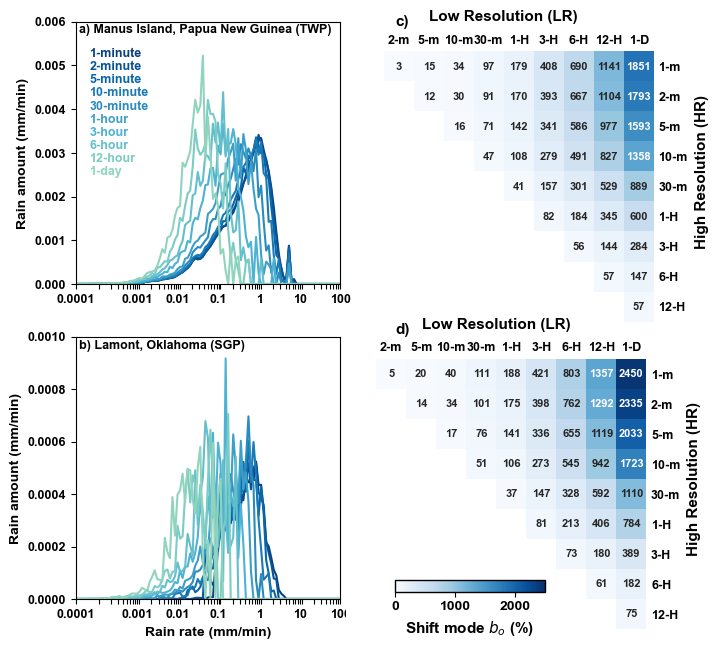

In [8]:
full_plotting(manus_rates, plains_rates, 'org_precip_rate_mean_bin', 'intensity_rt_bin')

# Figure-9: Joint distribution for temporal scaling

In [47]:
bincrates=make_bincrates()
bincrates=bincrates[1:]
otn=np.linspace(1,9,9)
xtickrates = np.concatenate([otn * 0.0001, otn * 0.001, otn * 0.01, otn * 0.1, otn, otn * 10])
tick_labels = ['0.0001','','','','','','','','',
               '0.001','','','','','','','','',
               '0.01','','','','','','','','',
               '0.1','','','','','','','','',
               '1','','','','','','','','',
               '10','','','','','','','','', 
               '100']
db=(bincrates[2]-bincrates[1])/bincrates[1]

ams_sizes = {
    "one_column": 3.2,
    "two_thirds": 4.5,
    "two_columns": 5.5,
    "more_than_two_columns": 6.5,
}

aspect_ratio = 1
width = 15
height = width * aspect_ratio

res = ['day', '12hr', '6hr', '3hr', '1hr', '30min', '10min', '5min', '2min', '1min']
res_label = ['1-day', '12-hr', '6-hr', '3-hr', '1-hr', '30-min', '10-min', '5-min', '2-min', '1-min']
res_l = res_label[::-1]
res_hr = res[::-1]
res_lr = res[::-1]

nrows = len(res)

# Auto-generate enough panel labels for any res length
import string
# With this (generates aa), ab), ac)... after z):
import itertools
def gen_labels():
    for length in range(1, 3):
        for combo in itertools.product(string.ascii_lowercase, repeat=length):
            yield ''.join(combo) + ')'

plabel = list(itertools.islice(gen_labels(), nrows * nrows))

n = 0
fig = plt.figure(figsize=(width, height))
plt.subplots_adjust(wspace=0.2, hspace=0.18, bottom=0.0, left=-0.1, right=0.9, top=0.9)

for i in range(nrows):      # rows
    hr = res[::-1][i]
    hr_l = res_l[i]
    hr_idx = nrows - 1 - i  # position in original res list

    first_valid_col = None
    last_valid_col = None

    # Pre-compute valid columns for this row
    valid_cols = []
    for j in range(nrows):
        lr_idx = nrows - 1 - j
        if lr_idx < hr_idx:
            valid_cols.append(j)
    if not valid_cols:
        continue
    first_valid_col = valid_cols[0]
    last_valid_col = valid_cols[-1]

    for j in range(nrows):  # columns
        lr = res[::-1][j]
        lr_l = res_l[j]
        hr_idx = nrows - 1 - i
        lr_idx = nrows - 1 - j

        if lr_idx >= hr_idx:
            continue

        data3 = xr.open_dataset(f'./../data/temporal/output/jointdist/manus_jointdist_{hr}_{lr}.nc')
        jdL = data3.jdL
        jdH = data3.jdH
        jdF = data3.jdF

        ax = fig.add_subplot(nrows, nrows, i * nrows + j + 1)

        levels=np.arange(0.25e-5,11e-5,1e-5)
        cs2 = ax.contour(jdL.LR_bin[1:], jdL.HR_bin[1:],
                         jdL[1:, 1:].T, linewidths=1, colors='#1d91c0', levels=levels, alpha=0.85)
        cs1 = ax.contour(jdH.HR_bin[1:], jdH.LR_bin[1:],
                        jdH[1:, 1:], linewidths=1, colors='#081d58', levels=levels,alpha=0.75)
        

        plt.xlim((1, 90))
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
        ax.tick_params(labelleft=False, left=False)


        if i == 0:
            ax.text(0.5, 1.2, lr_l, fontsize=14, fontweight="bold",
                    color='#1d91c0', transform=ax.transAxes,
                    ha='center', rotation=0, va='center')

        if j == first_valid_col:
            ax.tick_params(axis='x', which='both', bottom=True, top=False,
                           labeltop=False, labelbottom=True)
            ax.set_xlabel('LR rain rate', fontsize=10, fontweight="bold")
            ax.set_xticks(xtickrates)
            
            ax.text(-0.2, 0.5, hr_l, fontsize=14, fontweight="bold",
                    color='#081d58', transform=ax.transAxes,
                    ha='left', rotation=90, va='center')
            plt.setp(ax.get_xticklabels(), fontsize=8.5, fontweight='bold')

        if j == last_valid_col:
            ax.tick_params(axis='y', right=True, labelright=True, labelleft=False, left=False)
            ax.yaxis.set_label_position("right")
            ax.set_ylabel('HR rain rate', fontsize=10, fontweight="bold")
            ax.set_yticks(xtickrates)
            plt.setp(ax.get_yticklabels(), fontsize=8.5, fontweight='bold')
        lim_min = float(bincrates[7])
        lim_max = float(bincrates[89])

        ax.set_xlim([lim_min, lim_max])
        ax.set_ylim([lim_min, lim_max])
        ax.plot([lim_min, lim_max], [lim_min, lim_max], 'k-', alpha=0.5)

        for axis in ['top', 'bottom', 'left', 'right']:
            ax.spines[axis].set_linewidth(1.5)
        ymin, ymax = ax.get_ylim()
        t3=plt.text(1e-4,3,  str(n+1)+') '+lr_l+' → '+hr_l,fontsize=10,fontweight="bold")
        n += 1

# Horizontal arrow annotation
fig_ax = fig.add_axes([0, 0, 1, 1], zorder=-1)
fig_ax.axis('off')
fig_ax.annotate(
    '',
    xy=(0.7, 0.15),
    xytext=(0.2, 0.15),
    xycoords='figure fraction',
    textcoords='figure fraction',
    arrowprops=dict(arrowstyle="->", linewidth=3, color='#1d91c0')
)
fig.text(0.45, 0.16, 'Coarser Low Resolution (LR)', ha='center', va='bottom',
         fontsize=14, fontweight='bold', color='#1d91c0')

# Vertical arrow annotation
fig_ax = fig.add_axes([0, 0, 1, 1], zorder=-1)
fig_ax.axis('off')
fig_ax.annotate(
    '',
    xy=(0.1, 0.7),
    xytext=(0.1, 0.2),
    xycoords='figure fraction',
    textcoords='figure fraction',
    arrowprops=dict(arrowstyle='->', linewidth=3, color='#081d58'),
)
fig.text(0.12, 0.45, 'Finer Higher Resolution (HR)', rotation=90,
         va='center', ha='right', fontsize=14, fontweight='bold', color='#081d58')

filename = './../figs/fig9_temporal_joint_dist.pdf'
plt.savefig(filename, format="pdf", bbox_inches="tight", dpi=300)
plt.close()

# Table-1: Extreme rainfall

In [29]:
## Calculation of shift and narrowing modes
res=[10,25,100,200,500,1000]
n=0
hres=[];lres=[]
rx1=[];rx1m=[];rx1o=[]
difm=[];difo=[]
for i in range(0,len(res)):
    n=n+1
    for ii in range(n,len(res)):
        data1= xr.open_dataset('./../data/spatial/dist_data/raindist_data_'+str(res[i])+'_'+str(res[ii])+'km.nc')## Reading in data. Current structure is that the high resolution distribution is available in both input files.
        pamtH = data1.pamtH[1:].values ## rain amount of HR dataset
        pamtL= data1.pamtL[1:].values ## rain amount of LR dataset
        ppdfH= data1.ppdfH[1:].values ## rain frequency of HR dataset
        ppdfL=data1.ppdfL[1:].values ## rain frequency of LR dataset
        bincrates=data1.precipitation_bin[1:].values ## rain rate bins
        omodes=calcbo(pamtL,pamtH,bincrates)
        pamtbo=omodes[1]
        rx1day=calcrx1d(pamtH,bincrates)
        rx1day_o=calcrx1d(pamtbo,bincrates)
        diffo=100*(rx1day-rx1day_o)/rx1day_o
        rx1.append(rx1day)
        rx1o.append(rx1day_o)
        difo.append(diffo)
        hres.append(res[i])
        lres.append(res[ii])
df2=pd.DataFrame({'HR' : hres,'LR' : lres,'rx1day' : np.round(rx1,2),'Reproduced rx1day':np.round(rx1o,2),'Percentage Difference':np.round(difo,2)})

In [30]:
df2

,HR,LR,rx1day,Reproduced rx1day,Percentage Difference
0,10,25,298.95,291.96,2.39
1,10,100,298.95,266.67,12.10
2,10,200,298.95,232.83,28.40
3,10,500,298.95,165.26,80.90
4,10,1000,298.95,119.18,150.83
5,25,100,281.61,258.76,8.83
6,25,200,281.61,225.15,25.08
7,25,500,281.61,159.55,76.50
8,25,1000,281.61,115.46,143.89
9,100,200,229.81,200.69,14.51


# Table-2: Shift modes in observations

In [7]:
## Calculation of shift mode
res = [100, 200, 500, 1000]
datasets = ['IMERG','GPCP', 'CMORPH_v1.0_CRT', 'GIRAFE', 'PERSIANN_v1_r1']
dataset_names = {
    'IMERG': 'IMERG',
    'GPCP': 'GPCP',
    'CMORPH_v1.0_CRT': 'CMORPH',
    'GIRAFE': 'GIRAFE',
    'PERSIANN_v1_r1': 'PERSIANN'
}

# Prepare results
records = [];records2 = []

# Loop over resolution pairs
for i in range(len(res)):
    for ii in range(i + 1, len(res)):
        hr = res[i]
        lr = res[ii]
        row = {'HR': f'{hr//100}º', 'LR': f'{lr//100}º'}
        row2 = {'HR': f'{hr//100}º', 'LR': f'{lr//100}º'}

        for dd in datasets:
            file_path = './../data/frogs/raindist_'+dd+'_'+str(hr)+'_'+str(lr)+'km.nc'

            data1 = xr.open_dataset(file_path)
            pamtH = data1.pamtH[1:].values
            pamtL = data1.pamtL[1:].values
            ppdfH = data1.ppdfH[1:].values
            ppdfL = data1.ppdfL[1:].values
            bincrates = data1.precipitation_bin[1:].values

            # Calculate shift
            modes = calcbo(pamtL, pamtH, bincrates)
            #modes = calcbo(pamtL, pamtH, bincrates)
            row[dataset_names[dd]] = np.round(modes[0], 2)
            row2[dataset_names[dd]] = np.round(modes[2], 2)

        records.append(row)
        records2.append(row2)

# Create final DataFrame
df_summary = pd.DataFrame(records)
df_summary2 = pd.DataFrame(records2)

In [9]:
df_summary ## shift values

,HR,LR,IMERG,GPCP,CMORPH,GIRAFE,PERSIANN
0,1º,2º,13.57,14.90,16.65,12.95,8.30
1,1º,5º,50.84,55.62,63.58,50.89,31.83
2,1º,10º,110.99,120.29,137.98,112.82,71.01
3,2º,5º,32.81,35.44,40.24,33.59,21.73
4,2º,10º,85.78,91.72,104.02,88.42,57.90
5,5º,10º,39.88,41.55,45.48,41.04,29.71


In [10]:
df_summary2 ## error values

,HR,LR,IMERG,GPCP,CMORPH,GIRAFE,PERSIANN
0,1º,2º,30.84,30.37,16.81,20.12,19.60
1,1º,5º,31.29,30.31,17.29,6.65,25.95
2,1º,10º,32.63,31.55,22.59,17.31,32.49
3,2º,5º,31.29,30.26,18.02,14.28,29.23
4,2º,10º,32.45,31.55,23.63,22.90,34.87
5,5º,10º,32.29,31.43,27.16,29.06,37.86
